# Notes with Code on Linear Regression 

This notebook provides a brief introduction to linear regression with python implementation, covering all mathematical concepts with detailed explanations, derivations, and working code examples. This mainly used the [CS229 Stanford notes](https://cs229.stanford.edu/main_notes.pdf) as a reference.

## Table of Contents
1. Introduction to Supervised Learning
2. Linear Regression Setup
3. Section 1.1: LMS Algorithm (Gradient Descent)
4. Section 1.2: Normal Equations  
5. Section 1.3: Probabilistic Interpretation

---

In [1]:
# Import all necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy import stats
import time

# Set style and random seed for reproducibility
plt.style.use('default')
np.random.seed(42)

# Configure matplotlib for better rendering
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 12

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully!
NumPy version: 1.23.5


# 1. Introduction to Supervised Learning

Let's start by understanding the fundamental concepts of supervised learning through a concrete example.

## 1.1 The Housing Price Prediction Problem

Suppose we have a dataset giving the living areas and prices of 47 houses from Portland, Oregon. Our goal is to learn a function that can predict house prices based on their living areas.

### Key Terminology:

- **Input variables** $x^{(i)}$: Also called **input features** (living area in this example)
- **Output variable** $y^{(i)}$: Also called **target variable** (price)
- **Training example**: A pair $(x^{(i)}, y^{(i)})$
- **Training set**: Collection of $n$ training examples $\{(x^{(i)}, y^{(i)}); i = 1, \ldots, n\}$
- **Input space** $\mathcal{X}$: Space of input values
- **Output space** $\mathcal{Y}$: Space of output values

**Important note**: The superscript "$(i)$" is simply an index into the training set and has nothing to do with exponentiation.

In [2]:
# Create the Portland housing dataset from the PDF
# This represents a sample of the 47 houses mentioned
portland_data = {
    'living_area': [2104, 1600, 2400, 1416, 3000, 1985, 1534, 1427, 1380, 1494, 
                    1940, 2000, 1890, 4478, 1268, 2300, 1320, 1236, 2609, 3031,
                    1767, 1888, 1604, 1962, 3890, 1100, 1458, 2526, 2200, 2637],
    'price': [400, 330, 369, 232, 540, 315, 285, 250, 245, 259, 
              302, 320, 295, 715, 210, 355, 223, 199, 499, 599,
              252, 290, 262, 320, 765, 170, 240, 490, 345, 500]
}

# Convert to numpy arrays for easier manipulation
living_areas = np.array(portland_data['living_area'])
prices = np.array(portland_data['price'])
n_samples = len(living_areas)

print(f"Dataset: {n_samples} houses from Portland, Oregon")
print(f"Living area range: {living_areas.min()} - {living_areas.max()} sq ft")
print(f"Price range: ${prices.min()}k - ${prices.max()}k")

# Display first few examples
portland_df = pd.DataFrame(portland_data)
print("\nFirst 10 training examples:")
print(portland_df.head(10))

Dataset: 30 houses from Portland, Oregon
Living area range: 1100 - 4478 sq ft
Price range: $170k - $765k

First 10 training examples:
   living_area  price
0         2104    400
1         1600    330
2         2400    369
3         1416    232
4         3000    540
5         1985    315
6         1534    285
7         1427    250
8         1380    245
9         1494    259


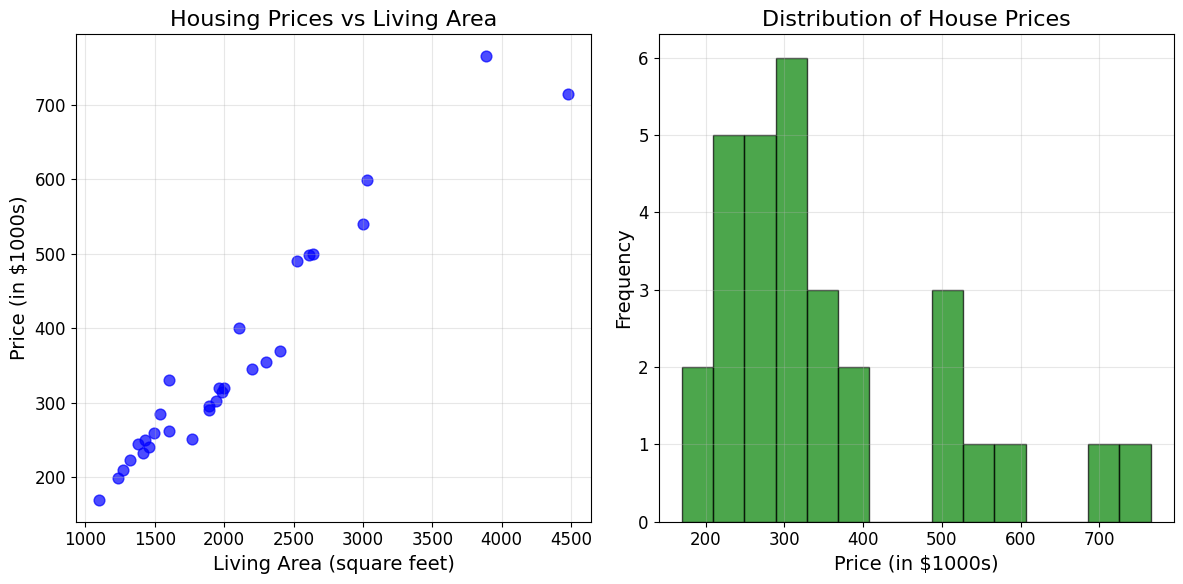

Correlation between living area and price: 0.968


In [3]:
# Plot the housing data as shown in the PDF
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.scatter(living_areas, prices, color='blue', alpha=0.7, s=60)
plt.xlabel('Living Area (square feet)')
plt.ylabel('Price (in $1000s)')
plt.title('Housing Prices vs Living Area')
plt.grid(True, alpha=0.3)

# Add some statistics
plt.subplot(1, 2, 2)
plt.hist(prices, bins=15, alpha=0.7, color='green', edgecolor='black')
plt.xlabel('Price (in $1000s)')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Correlation between living area and price: {np.corrcoef(living_areas, prices)[0,1]:.3f}")

## 1.2 The Supervised Learning Framework

**Goal**: Given a training set, learn a function $h : \mathcal{X} \mapsto \mathcal{Y}$ so that $h(x)$ is a "good" predictor for the corresponding value of $y$.

For historical reasons, this function $h$ is called a **hypothesis**.

### The Learning Process:

```
Training Set → Learning Algorithm → h (hypothesis)
```

Then: $x$ (living area of house) → $h$ → predicted $y$ (predicted price)

### Problem Types:

- **Regression Problem**: When the target variable is continuous (like house prices)
- **Classification Problem**: When $y$ takes on discrete values (like house vs. apartment)

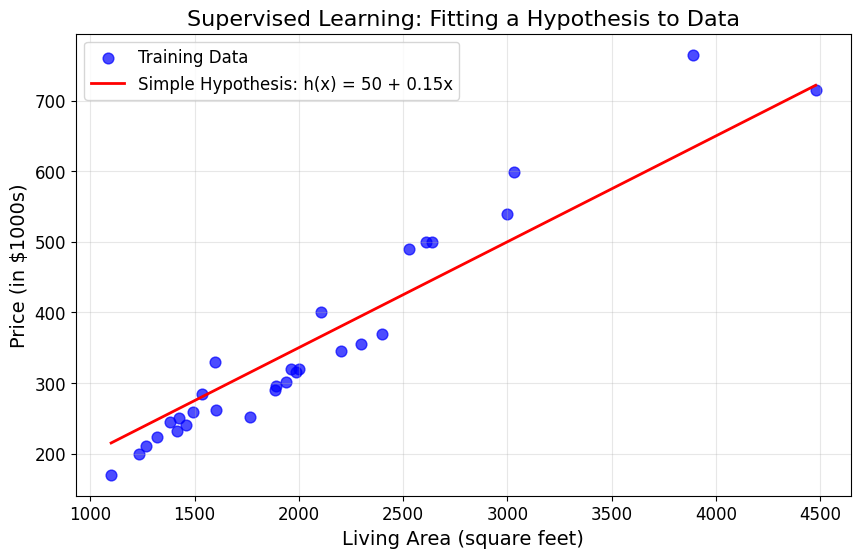

Mean Squared Error of simple hypothesis: 2153.47

This shows we need a systematic way to find good parameters!


In [4]:
# Demonstrate the concept of hypothesis function
# Let's try a simple linear hypothesis as a starting point

def simple_hypothesis(x, theta0=50, theta1=0.15):
    """Simple linear hypothesis: h(x) = theta0 + theta1 * x"""
    return theta0 + theta1 * x

# Generate predictions using our simple hypothesis
x_line = np.linspace(living_areas.min(), living_areas.max(), 100)
y_pred_simple = simple_hypothesis(x_line)

plt.figure(figsize=(10, 6))
plt.scatter(living_areas, prices, color='blue', alpha=0.7, s=60, label='Training Data')
plt.plot(x_line, y_pred_simple, 'r-', linewidth=2, label='Simple Hypothesis: h(x) = 50 + 0.15x')
plt.xlabel('Living Area (square feet)')
plt.ylabel('Price (in $1000s)')
plt.title('Supervised Learning: Fitting a Hypothesis to Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate how well our simple hypothesis performs
y_pred_data = simple_hypothesis(living_areas)
error = np.mean((y_pred_data - prices)**2)
print(f"Mean Squared Error of simple hypothesis: {error:.2f}")
print("\nThis shows we need a systematic way to find good parameters!")

---

# 2. Chapter 1: Linear Regression

## 2.1 Extended Dataset with Multiple Features

To make our housing example more interesting, let's consider a richer dataset that also includes the number of bedrooms in each house.

Now our features are **two-dimensional vectors** in $\mathbb{R}^2$:
- $x_1^{(i)}$: living area of the $i$-th house
- $x_2^{(i)}$: number of bedrooms of the $i$-th house

In [5]:
# Extend our dataset with number of bedrooms
bedrooms = np.array([3, 3, 3, 2, 4, 3, 2, 2, 2, 2, 
                     3, 3, 3, 5, 1, 4, 2, 2, 4, 4,
                     3, 3, 2, 3, 6, 1, 2, 4, 3, 4])

# Create extended dataframe
extended_data = pd.DataFrame({
    'living_area': living_areas,
    'bedrooms': bedrooms,
    'price': prices
})

print("Extended Housing Dataset:")
print(extended_data.head(10))
print(f"\nDataset statistics:")
print(extended_data.describe())

Extended Housing Dataset:
   living_area  bedrooms  price
0         2104         3    400
1         1600         3    330
2         2400         3    369
3         1416         2    232
4         3000         4    540
5         1985         3    315
6         1534         2    285
7         1427         2    250
8         1380         2    245
9         1494         2    259

Dataset statistics:
       living_area   bedrooms       price
count    30.000000  30.000000   30.000000
mean   2048.133333   2.933333  352.533333
std     780.668623   1.112107  149.799575
min    1100.000000   1.000000  170.000000
25%    1467.000000   2.000000  250.500000
50%    1915.000000   3.000000  308.500000
75%    2375.000000   3.750000  392.250000
max    4478.000000   6.000000  765.000000


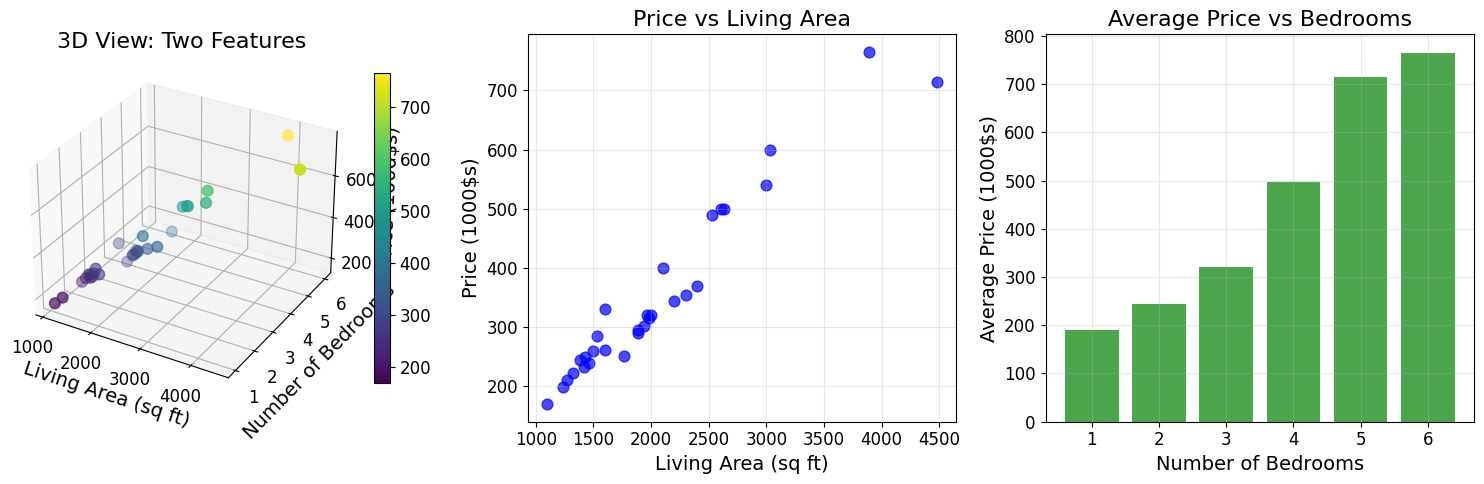

In [6]:
# Visualize the extended dataset
fig = plt.figure(figsize=(15, 5))

# 3D scatter plot
ax1 = fig.add_subplot(131, projection='3d')
scatter = ax1.scatter(living_areas, bedrooms, prices, c=prices, cmap='viridis', s=60)
ax1.set_xlabel('Living Area (sq ft)')
ax1.set_ylabel('Number of Bedrooms')
ax1.set_zlabel('Price (1000$s)')
ax1.set_title('3D View: Two Features')
plt.colorbar(scatter, ax=ax1, shrink=0.8)

# 2D projections
ax2 = fig.add_subplot(132)
ax2.scatter(living_areas, prices, alpha=0.7, s=60, color='blue')
ax2.set_xlabel('Living Area (sq ft)')
ax2.set_ylabel('Price (1000$s)')
ax2.set_title('Price vs Living Area')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(133)
bedroom_avg = extended_data.groupby('bedrooms')['price'].mean()
ax3.bar(bedroom_avg.index, bedroom_avg.values, alpha=0.7, color='green')
ax3.set_xlabel('Number of Bedrooms')
ax3.set_ylabel('Average Price (1000$s)')
ax3.set_title('Average Price vs Bedrooms')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.2 Linear Hypothesis Function

To perform supervised learning, we must decide how to represent functions/hypotheses $h$ in a computer. As an initial choice, let's approximate $y$ as a **linear function** of $x$:

$$h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2$$

Here, the $\theta_i$'s are the **parameters** (also called **weights**) that parameterize the space of linear functions mapping from $\mathcal{X}$ to $\mathcal{Y}$.

### Vectorized Notation

To simplify notation, we introduce the convention of letting $x_0 = 1$ (the **intercept term**), so that:

$$h(x) = \sum_{i=0}^{d} \theta_i x_i = \theta^T x$$

where:
- $\theta$ and $x$ are both viewed as vectors
- $d$ is the number of input variables (not counting $x_0$)

In [7]:
def linear_hypothesis(X, theta):
    """
    Compute linear hypothesis h_theta(x) = theta^T * x
    
    Args:
        X: Feature matrix (n_samples, n_features) with intercept term
        theta: Parameter vector (n_features,)
    
    Returns:
        predictions: h_theta(x) for each sample
    """
    return X @ theta

# Create feature matrices with intercept term
# For single feature (living area only)
X_single = np.column_stack([np.ones(n_samples), living_areas])

# For multiple features (living area + bedrooms)
X_multi = np.column_stack([np.ones(n_samples), living_areas, bedrooms])

print("Single feature matrix X (with intercept):")
print(f"Shape: {X_single.shape}")
print("First 5 rows:")
print(X_single[:5])

print("\nMultiple feature matrix X (with intercept):")
print(f"Shape: {X_multi.shape}")
print("First 5 rows:")
print(X_multi[:5])

Single feature matrix X (with intercept):
Shape: (30, 2)
First 5 rows:
[[1.000e+00 2.104e+03]
 [1.000e+00 1.600e+03]
 [1.000e+00 2.400e+03]
 [1.000e+00 1.416e+03]
 [1.000e+00 3.000e+03]]

Multiple feature matrix X (with intercept):
Shape: (30, 3)
First 5 rows:
[[1.000e+00 2.104e+03 3.000e+00]
 [1.000e+00 1.600e+03 3.000e+00]
 [1.000e+00 2.400e+03 3.000e+00]
 [1.000e+00 1.416e+03 2.000e+00]
 [1.000e+00 3.000e+03 4.000e+00]]


In [8]:
# Example with different parameter values
theta_examples = [
    np.array([50, 0.1]),  # Single feature
    np.array([30, 0.15, 50])  # Multiple features
]

print("Testing different hypothesis functions:")
print("\n1. Single feature model: h(x) = theta_0 + theta_1 * living_area")
theta1 = theta_examples[0]
predictions1 = linear_hypothesis(X_single, theta1)
print(f"Parameters: theta = {theta1}")
print(f"First 5 predictions: {predictions1[:5]}")
print(f"Actual prices:       {prices[:5]}")

print("\n2. Multiple feature model: h(x) = theta_0 + theta_1 * living_area + theta_2 * bedrooms")
theta2 = theta_examples[1]
predictions2 = linear_hypothesis(X_multi, theta2)
print(f"Parameters: theta = {theta2}")
print(f"First 5 predictions: {predictions2[:5]}")
print(f"Actual prices:       {prices[:5]}")

Testing different hypothesis functions:

1. Single feature model: h(x) = theta_0 + theta_1 * living_area
Parameters: theta = [50.   0.1]
First 5 predictions: [260.4 210.  290.  191.6 350. ]
Actual prices:       [400 330 369 232 540]

2. Multiple feature model: h(x) = theta_0 + theta_1 * living_area + theta_2 * bedrooms
Parameters: theta = [30.    0.15 50.  ]
First 5 predictions: [495.6 420.  540.  342.4 680. ]
Actual prices:       [400 330 369 232 540]


## 2.3 The Cost Function

Now, given a training set, how do we pick or learn the parameters $\theta$? 

One reasonable method is to make $h(x)$ close to $y$, at least for the training examples we have. To formalize this, we define a function that measures how close the $h(x^{(i)})$'s are to the corresponding $y^{(i)}$'s.

We define the **cost function**:

$$J(\theta) = \frac{1}{2} \sum_{i=1}^{n} \left(h_\theta(x^{(i)}) - y^{(i)}\right)^2$$

This is the familiar **least-squares cost function** that gives rise to the **ordinary least squares regression model**.

### Why This Cost Function?

- **Intuitive**: Penalizes predictions that are far from actual values
- **Differentiable**: Allows us to use calculus-based optimization
- **Convex**: Has a unique global minimum (no local minima)

In [9]:
def cost_function(X, y, theta):
    """
    Compute the least squares cost function J(theta)
    
    Args:
        X: Feature matrix (n_samples, n_features)
        y: Target vector (n_samples,)
        theta: Parameter vector (n_features,)
    
    Returns:
        cost: J(theta)
    """
    m = len(y)
    predictions = linear_hypothesis(X, theta)
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

# Calculate costs for our example hypotheses
cost1 = cost_function(X_single, prices, theta_examples[0])
cost2 = cost_function(X_multi, prices, theta_examples[1])

print(f"Cost for single feature model: J(theta) = {cost1:.2f}")
print(f"Cost for multiple feature model: J(theta) = {cost2:.2f}")
print("\nLower cost indicates better fit to training data")

Cost for single feature model: J(theta) = 7627.60
Cost for multiple feature model: J(theta) = 9562.00

Lower cost indicates better fit to training data


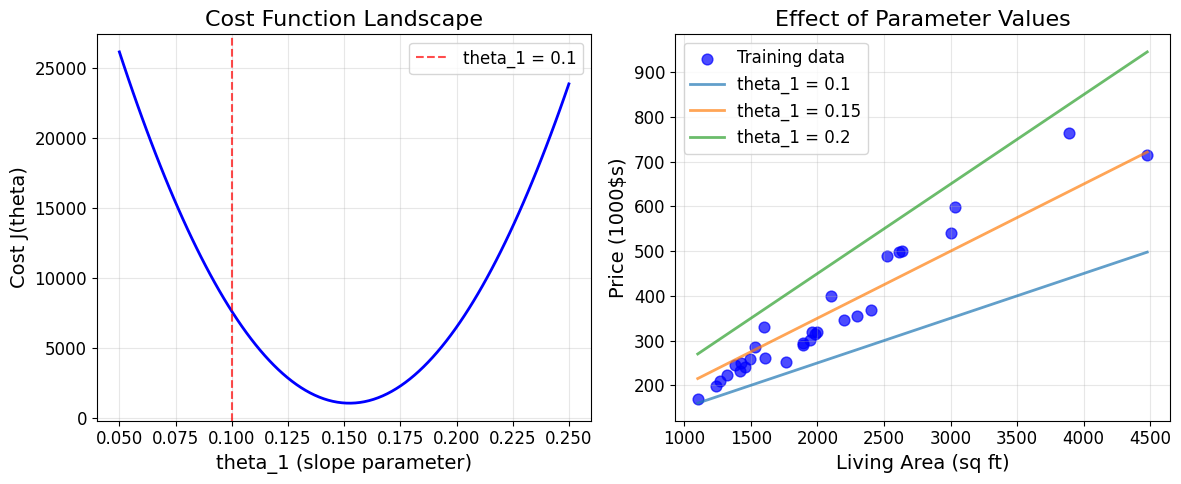

Approximate optimal theta_1: 0.1530
Minimum cost: 1064.10


In [10]:
# Visualize cost function landscape for single parameter
# Fix theta_0 = 50, vary theta_1
theta1_range = np.linspace(0.05, 0.25, 100)
costs = []

for t1 in theta1_range:
    theta_temp = np.array([50, t1])
    cost = cost_function(X_single, prices, theta_temp)
    costs.append(cost)

plt.figure(figsize=(12, 5))

# Plot cost landscape
plt.subplot(1, 2, 1)
plt.plot(theta1_range, costs, 'b-', linewidth=2)
plt.axvline(theta_examples[0][1], color='red', linestyle='--', alpha=0.7, 
           label=f'theta_1 = {theta_examples[0][1]}')
plt.xlabel('theta_1 (slope parameter)')
plt.ylabel('Cost J(theta)')
plt.title('Cost Function Landscape')
plt.legend()
plt.grid(True, alpha=0.3)

# Show the effect of parameter choice on fit
plt.subplot(1, 2, 2)
plt.scatter(living_areas, prices, alpha=0.7, s=60, color='blue', label='Training data')

# Show fits with different theta_1 values
x_line = np.linspace(living_areas.min(), living_areas.max(), 100)
for i, t1 in enumerate([0.1, 0.15, 0.2]):
    y_line = 50 + t1 * x_line
    plt.plot(x_line, y_line, linewidth=2, alpha=0.7, 
            label=f'theta_1 = {t1}')

plt.xlabel('Living Area (sq ft)')
plt.ylabel('Price (1000$s)')
plt.title('Effect of Parameter Values')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Find the minimum cost and corresponding theta_1
min_idx = np.argmin(costs)
optimal_theta1 = theta1_range[min_idx]
min_cost = costs[min_idx]
print(f"Approximate optimal theta_1: {optimal_theta1:.4f}")
print(f"Minimum cost: {min_cost:.2f}")

---

# 3. Section 1.1: LMS Algorithm (Gradient Descent)

We want to choose $\theta$ so as to minimize $J(\theta)$. Let's use a **search algorithm** that starts with some initial guess for $\theta$, and repeatedly changes $\theta$ to make $J(\theta)$ smaller, until we converge to a value that minimizes $J(\theta)$.

## 3.1 Gradient Descent Algorithm

The **gradient descent** algorithm starts with some initial $\theta$, and repeatedly performs the update:

$$\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$$

(This update is simultaneously performed for all values of $j = 0, \ldots, d$.)

Here, $\alpha$ is called the **learning rate**. This algorithm repeatedly takes a step in the direction of steepest decrease of $J$.

## 3.2 Deriving the Gradient

To implement this algorithm, we need to work out the partial derivative term. Let's start with a single training example $(x, y)$:

$$\frac{\partial}{\partial \theta_j} J(\theta) = \frac{\partial}{\partial \theta_j} \frac{1}{2}(h_\theta(x) - y)^2$$

$$= (h_\theta(x) - y) \cdot \frac{\partial}{\partial \theta_j} (h_\theta(x) - y)$$

$$= (h_\theta(x) - y) \cdot \frac{\partial}{\partial \theta_j} \left(\sum_{i=0}^{d} \theta_i x_i - y\right)$$

$$= (h_\theta(x) - y) \cdot x_j$$

## 3.3 LMS Update Rule

For a single training example, this gives us the update rule:

$$\theta_j := \theta_j + \alpha \left(y^{(i)} - h_\theta(x^{(i)})\right) x_j^{(i)}$$

This is called the **LMS update rule** (LMS stands for "least mean squares"), also known as the **Widrow-Hoff learning rule**.

### Intuition Behind LMS Rule:
- Update magnitude is proportional to the **error term** $(y^{(i)} - h_\theta(x^{(i)}))$
- If prediction is close to actual value → small update
- If prediction has large error → large update

In [11]:
def compute_gradient(X, y, theta):
    """
    Compute the gradient of the cost function
    
    Args:
        X: Feature matrix (n_samples, n_features)
        y: Target vector (n_samples,)
        theta: Parameter vector (n_features,)
    
    Returns:
        gradient: Gradient vector (n_features,)
    """
    m = len(y)
    predictions = linear_hypothesis(X, theta)
    errors = predictions - y
    gradient = (1/m) * X.T @ errors
    return gradient

def lms_single_update(x, y, theta, alpha):
    """
    LMS update rule for a single training example
    
    Args:
        x: Single feature vector (n_features,)
        y: Single target value
        theta: Current parameter vector (n_features,)
        alpha: Learning rate
    
    Returns:
        theta_new: Updated parameter vector
    """
    prediction = np.dot(theta, x)
    error = y - prediction
    theta_new = theta + alpha * error * x
    return theta_new

# Demonstrate single LMS update
print("LMS Update Rule Demonstration")
print("=" * 40)

# Start with some parameters
theta_init = np.array([50, 0.1])
alpha = 0.0001  # Small learning rate for stability

# Use first training example
x_example = X_single[0]  # [1, 2104]
y_example = prices[0]    # 400

print(f"Initial parameters: theta = {theta_init}")
print(f"Training example: x = {x_example}, y = {y_example}")

# Make prediction
pred_before = np.dot(theta_init, x_example)
error_before = y_example - pred_before
print(f"Prediction before update: {pred_before:.1f}")
print(f"Error: {error_before:.1f}")

# Apply LMS update
theta_updated = lms_single_update(x_example, y_example, theta_init, alpha)
pred_after = np.dot(theta_updated, x_example)

print(f"\nUpdated parameters: theta = {theta_updated}")
print(f"Prediction after update: {pred_after:.1f}")
print(f"Improvement in prediction: {abs(error_before) - abs(y_example - pred_after):.1f}")

LMS Update Rule Demonstration
Initial parameters: theta = [50.   0.1]
Training example: x = [1.000e+00 2.104e+03], y = 400
Prediction before update: 260.4
Error: 139.6

Updated parameters: theta = [50.01396 29.47184]
Prediction after update: 62058.8
Improvement in prediction: -61519.2


## 3.4 Batch Gradient Descent

For a training set with more than one example, we modify the method as follows:

**Repeat until convergence:**
$$\theta_j := \theta_j + \alpha \sum_{i=1}^{n} \left(y^{(i)} - h_\theta(x^{(i)})\right) x_j^{(i)} \quad \text{(for every } j\text{)}$$

In vector form:
$$\theta := \theta + \alpha \sum_{i=1}^{n} \left(y^{(i)} - h_\theta(x^{(i)})\right) x^{(i)}$$

The quantity in the summation is just $\frac{\partial J(\theta)}{\partial \theta_j}$, so this is simply **gradient descent** on the original cost function $J$.

This method looks at every example in the entire training set on every step, and is called **batch gradient descent**.

### Important Properties:
- For linear regression, $J$ is a **convex quadratic function**
- Has only one global optimum, no local minima
- Gradient descent always converges (assuming learning rate $\alpha$ is not too large)

In [12]:
def batch_gradient_descent(X, y, alpha, num_iterations, theta_init=None):
    """
    Batch gradient descent for linear regression
    
    Args:
        X: Feature matrix (n_samples, n_features)
        y: Target vector (n_samples,)
        alpha: Learning rate
        num_iterations: Number of iterations
        theta_init: Initial parameter vector
    
    Returns:
        theta: Final parameters
        cost_history: Cost at each iteration
        theta_history: Parameters at each iteration
    """
    n_features = X.shape[1]
    
    # Initialize parameters
    if theta_init is None:
        theta = np.zeros(n_features)
    else:
        theta = theta_init.copy()
    
    cost_history = []
    theta_history = []
    
    for i in range(num_iterations):
        # Compute cost and store history
        cost = cost_function(X, y, theta)
        cost_history.append(cost)
        theta_history.append(theta.copy())
        
        # Compute gradient
        gradient = compute_gradient(X, y, theta)
        
        # Update parameters
        theta = theta - alpha * gradient
        
        # Print progress
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {cost:.4f}, theta = {theta}")
    
    return theta, cost_history, theta_history

# Run batch gradient descent on single feature dataset
print("Batch Gradient Descent - Single Feature")
print("=" * 45)

alpha = 0.0000001  # Very small learning rate due to large feature values
num_iterations = 200
theta_init = np.array([0, 0])

theta_final, cost_history, theta_history = batch_gradient_descent(
    X_single, prices, alpha, num_iterations, theta_init
)

print(f"\nFinal parameters: theta = {theta_final}")
print(f"Final cost: {cost_history[-1]:.4f}")

# Calculate the linear model equation
print(f"\nLinear model: h(x) = {theta_final[0]:.2f} + {theta_final[1]:.6f} * living_area")

Batch Gradient Descent - Single Feature
Iteration 0: Cost = 72985.8333, theta = [3.52533333e-05 8.31421300e-02]
Iteration 100: Cost = 738.2967, theta = [3.98870836e-05 1.73792828e-01]

Final parameters: theta = [6.05295419e-06 1.73792843e-01]
Final cost: 738.2966

Linear model: h(x) = 0.00 + 0.173793 * living_area


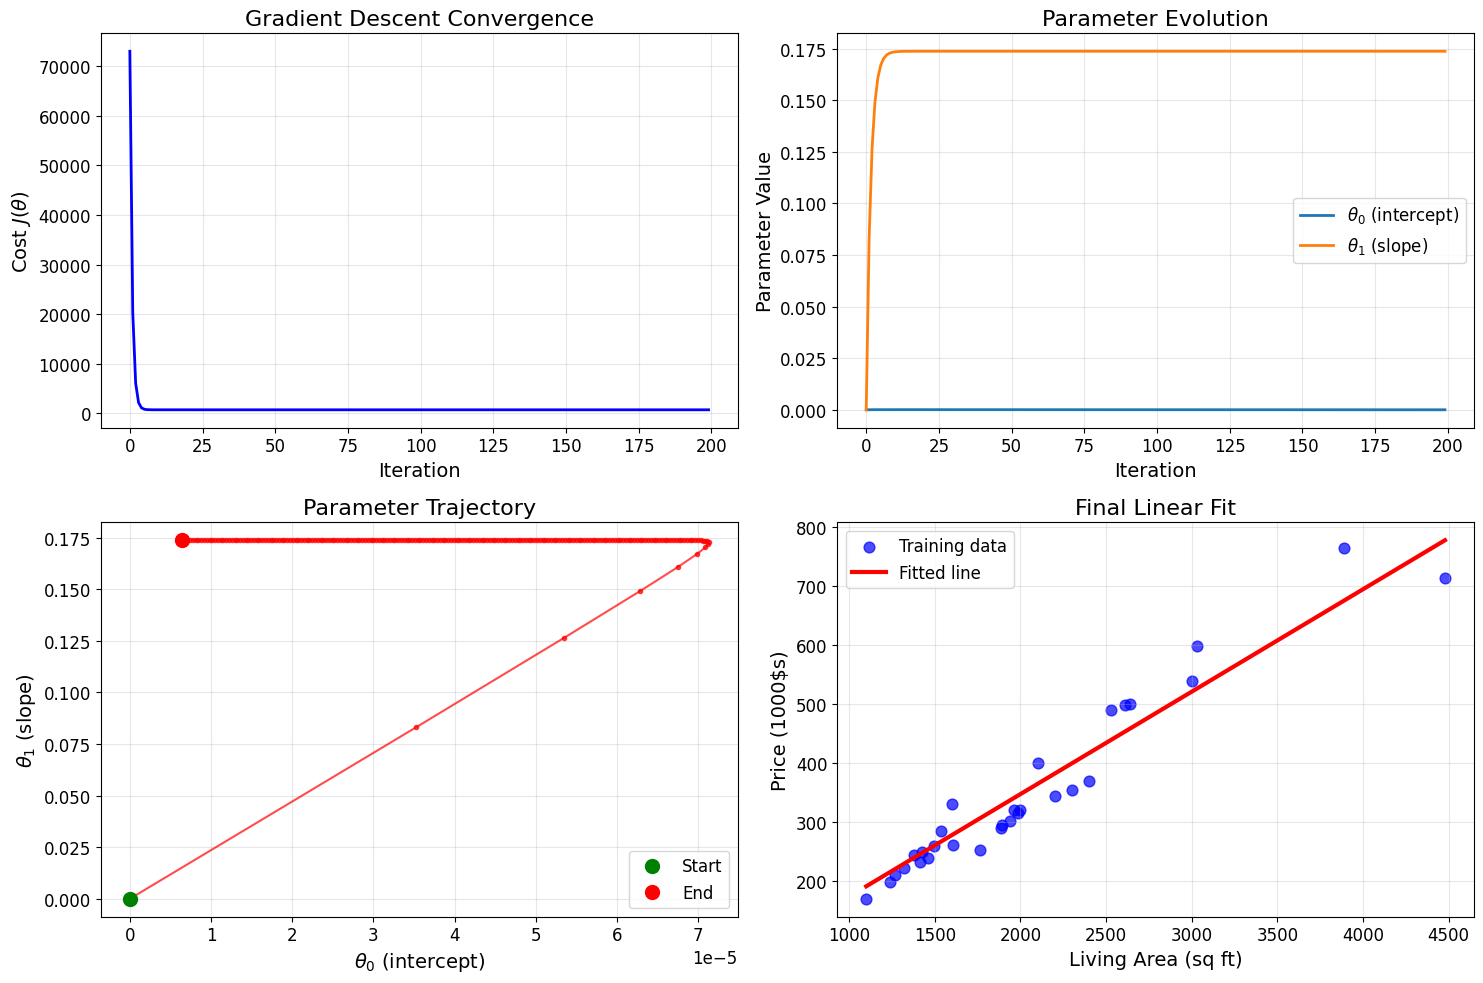

In [13]:
# Visualize gradient descent convergence
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Cost function over iterations
axes[0, 0].plot(cost_history, 'b-', linewidth=2)
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('Cost $J(\\theta)$')
axes[0, 0].set_title('Gradient Descent Convergence')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Parameter evolution
theta_history_array = np.array(theta_history)
axes[0, 1].plot(theta_history_array[:, 0], label='$\\theta_0$ (intercept)', linewidth=2)
axes[0, 1].plot(theta_history_array[:, 1], label='$\\theta_1$ (slope)', linewidth=2)
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('Parameter Value')
axes[0, 1].set_title('Parameter Evolution')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Parameter trajectory (if 2D)
axes[1, 0].plot(theta_history_array[:, 0], theta_history_array[:, 1], 'ro-', markersize=3, alpha=0.7)
axes[1, 0].plot(theta_history_array[0, 0], theta_history_array[0, 1], 'go', markersize=10, label='Start')
axes[1, 0].plot(theta_history_array[-1, 0], theta_history_array[-1, 1], 'ro', markersize=10, label='End')
axes[1, 0].set_xlabel('$\\theta_0$ (intercept)')
axes[1, 0].set_ylabel('$\\theta_1$ (slope)')
axes[1, 0].set_title('Parameter Trajectory')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Final fit
axes[1, 1].scatter(living_areas, prices, alpha=0.7, s=60, color='blue', label='Training data')
x_line = np.linspace(living_areas.min(), living_areas.max(), 100)
y_line = theta_final[0] + theta_final[1] * x_line
axes[1, 1].plot(x_line, y_line, 'r-', linewidth=3, label='Fitted line')
axes[1, 1].set_xlabel('Living Area (sq ft)')
axes[1, 1].set_ylabel('Price (1000$s)')
axes[1, 1].set_title('Final Linear Fit')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Feature Normalization for Better Convergence

The slow convergence above is due to the large difference in feature scales. Let's implement **feature normalization** to improve gradient descent performance.

In [14]:
def normalize_features(X, exclude_intercept=True):
    """
    Normalize features using z-score normalization
    
    Args:
        X: Feature matrix (n_samples, n_features)
        exclude_intercept: If True, don't normalize the first column (intercept)
    
    Returns:
        X_norm: Normalized feature matrix
        mu: Mean of each feature
        sigma: Standard deviation of each feature
    """
    X_norm = X.copy().astype(float)
    
    start_idx = 1 if exclude_intercept else 0
    
    mu = np.mean(X[:, start_idx:], axis=0)
    sigma = np.std(X[:, start_idx:], axis=0)
    
    # Avoid division by zero
    sigma[sigma == 0] = 1
    
    X_norm[:, start_idx:] = (X[:, start_idx:] - mu) / sigma
    
    return X_norm, mu, sigma

def denormalize_theta(theta_norm, mu, sigma, exclude_intercept=True):
    """
    Convert normalized parameters back to original scale
    """
    theta = theta_norm.copy()
    
    if exclude_intercept and len(theta) > 1:
        # Adjust slope parameters
        theta[1:] = theta_norm[1:] / sigma
        # Adjust intercept
        theta[0] = theta_norm[0] - np.sum(theta_norm[1:] * mu / sigma)
    
    return theta

# Normalize features and run gradient descent again
print("Feature Normalization Results")
print("=" * 35)

X_single_norm, mu_single, sigma_single = normalize_features(X_single)
print(f"Original living area: mean = {living_areas.mean():.1f}, std = {living_areas.std():.1f}")
print(f"Normalized living area: mean = {X_single_norm[:, 1].mean():.6f}, std = {X_single_norm[:, 1].std():.6f}")

# Run gradient descent with normalized features
alpha_norm = 0.01  # Much higher learning rate possible now!
num_iterations_norm = 500

theta_norm, cost_history_norm, _ = batch_gradient_descent(
    X_single_norm, prices, alpha_norm, num_iterations_norm
)

# Convert back to original scale
theta_denorm = denormalize_theta(theta_norm, mu_single, sigma_single)

print(f"\nNormalized space parameters: {theta_norm}")
print(f"Original space parameters: {theta_denorm}")
print(f"Final cost: {cost_history_norm[-1]:.4f}")

Feature Normalization Results
Original living area: mean = 2048.1, std = 767.5
Normalized living area: mean = 0.000000, std = 1.000000
Iteration 0: Cost = 72985.8333, theta = [3.52533333 1.42513747]
Iteration 100: Cost = 10376.9289, theta = [224.78511797  90.87075323]
Iteration 200: Cost = 1988.6082, theta = [305.77335497 123.61074138]
Iteration 300: Cost = 864.7437, theta = [335.41766898 135.5946359 ]
Iteration 400: Cost = 714.1687, theta = [346.26844664 139.98112887]

Normalized space parameters: [350.21701904 141.57736332]
Original space parameters: [-27.56992913   0.18445427]
Final cost: 694.0581


## 3.5 Stochastic Gradient Descent

There's an alternative to batch gradient descent that also works very well:

**Loop:**
```
for i = 1 to n:
    θⱼ := θⱼ + α(y⁽ⁱ⁾ - h_θ(x⁽ⁱ⁾))x_j⁽ⁱ⁾  (for every j)
```

In vector form:
$$\theta := \theta + \alpha \left(y^{(i)} - h_\theta(x^{(i)})\right) x^{(i)}$$

This algorithm is called **stochastic gradient descent** (also **incremental gradient descent**).

### Key Differences:
- **Batch GD**: Scans through entire training set before taking a single step
- **Stochastic GD**: Updates parameters after each training example
- **SGD advantages**: Can start making progress immediately, often faster for large datasets
- **SGD disadvantages**: May oscillate around minimum, doesn't converge exactly

In [15]:
def stochastic_gradient_descent(X, y, alpha, num_epochs, theta_init=None):
    """
    Stochastic gradient descent for linear regression
    
    Args:
        X: Feature matrix (n_samples, n_features)
        y: Target vector (n_samples,)
        alpha: Learning rate
        num_epochs: Number of passes through the dataset
        theta_init: Initial parameter vector
    
    Returns:
        theta: Final parameters
        cost_history: Cost at each epoch
    """
    n_samples, n_features = X.shape
    
    # Initialize parameters
    if theta_init is None:
        theta = np.zeros(n_features)
    else:
        theta = theta_init.copy()
    
    cost_history = []
    
    for epoch in range(num_epochs):
        # Shuffle the data for each epoch
        indices = np.random.permutation(n_samples)
        
        for i in indices:
            # Update using single example
            theta = lms_single_update(X[i], y[i], theta, alpha)
        
        # Record cost at end of epoch
        cost = cost_function(X, y, theta)
        cost_history.append(cost)
        
        if epoch % 50 == 0:
            print(f"Epoch {epoch}: Cost = {cost:.4f}")
    
    return theta, cost_history

# Run stochastic gradient descent
print("Stochastic Gradient Descent")
print("=" * 30)

alpha_sgd = 0.01
num_epochs = 200

theta_sgd, cost_history_sgd = stochastic_gradient_descent(
    X_single_norm, prices, alpha_sgd, num_epochs
)

theta_sgd_denorm = denormalize_theta(theta_sgd, mu_single, sigma_single)

print(f"\nSGD final parameters (original scale): {theta_sgd_denorm}")
print(f"BGD final parameters (original scale): {theta_denorm}")
print(f"\nSGD final cost: {cost_history_sgd[-1]:.4f}")
print(f"BGD final cost: {cost_history_norm[-1]:.4f}")

Stochastic Gradient Descent
Epoch 0: Cost = 39949.7778
Epoch 50: Cost = 690.9346
Epoch 100: Cost = 691.2030
Epoch 150: Cost = 690.9294

SGD final parameters (original scale): [-26.88154797   0.18505328]
BGD final parameters (original scale): [-27.56992913   0.18445427]

SGD final cost: 691.0677
BGD final cost: 694.0581


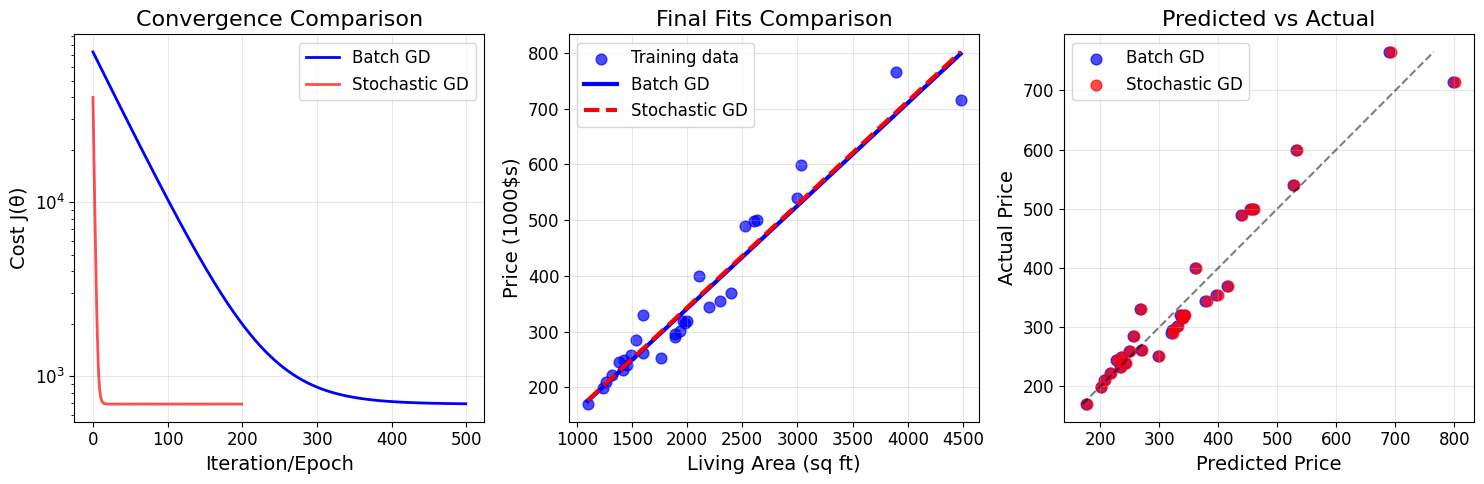


Model Performance (R² score):
Batch GD: 0.9360
Stochastic GD: 0.9363


In [16]:
# Compare batch vs stochastic gradient descent
plt.figure(figsize=(15, 5))

# Plot 1: Cost convergence comparison
plt.subplot(1, 3, 1)
plt.plot(cost_history_norm, 'b-', label='Batch GD', linewidth=2)
plt.plot(cost_history_sgd, 'r-', label='Stochastic GD', linewidth=2, alpha=0.7)
plt.xlabel('Iteration/Epoch')
plt.ylabel('Cost J(θ)')
plt.title('Convergence Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Plot 2: Final fits comparison
plt.subplot(1, 3, 2)
plt.scatter(living_areas, prices, alpha=0.7, s=60, color='blue', label='Training data')
x_line = np.linspace(living_areas.min(), living_areas.max(), 100)
y_line_bgd = theta_denorm[0] + theta_denorm[1] * x_line
y_line_sgd = theta_sgd_denorm[0] + theta_sgd_denorm[1] * x_line
plt.plot(x_line, y_line_bgd, 'b-', linewidth=3, label='Batch GD')
plt.plot(x_line, y_line_sgd, 'r--', linewidth=3, label='Stochastic GD')
plt.xlabel('Living Area (sq ft)')
plt.ylabel('Price (1000$s)')
plt.title('Final Fits Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Prediction accuracy
plt.subplot(1, 3, 3)
pred_bgd = linear_hypothesis(X_single, theta_denorm)
pred_sgd = linear_hypothesis(X_single, theta_sgd_denorm)

plt.scatter(pred_bgd, prices, alpha=0.7, s=60, label='Batch GD', color='blue')
plt.scatter(pred_sgd, prices, alpha=0.7, s=60, label='Stochastic GD', color='red')
plt.plot([prices.min(), prices.max()], [prices.min(), prices.max()], 'k--', alpha=0.5)
plt.xlabel('Predicted Price')
plt.ylabel('Actual Price')
plt.title('Predicted vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate R² scores
def r_squared(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

r2_bgd = r_squared(prices, pred_bgd)
r2_sgd = r_squared(prices, pred_sgd)

print(f"\nModel Performance (R² score):")
print(f"Batch GD: {r2_bgd:.4f}")
print(f"Stochastic GD: {r2_sgd:.4f}")

---

# 4. Section 1.2: The Normal Equations

Gradient descent gives one way of minimizing $J$. Let's discuss a second way of doing so, this time performing the minimization **explicitly** and without resorting to an iterative algorithm.

In this method, we will minimize $J$ by explicitly taking its derivatives with respect to the $\theta_j$'s, and setting them to zero.

## 4.1 Matrix Derivatives

To enable us to do this without writing pages of algebra, let's introduce some notation for doing calculus with matrices.

For a function $f : \mathbb{R}^{n \times d} \mapsto \mathbb{R}$ mapping from $n$-by-$d$ matrices to real numbers, we define the derivative of $f$ with respect to $A$ to be:

$$\nabla_A f(A) = \begin{bmatrix}
\frac{\partial f}{\partial A_{11}} & \cdots & \frac{\partial f}{\partial A_{1d}} \\
\vdots & \ddots & \vdots \\
\frac{\partial f}{\partial A_{n1}} & \cdots & \frac{\partial f}{\partial A_{nd}}
\end{bmatrix}$$

The gradient $\nabla_A f(A)$ is itself an $n$-by-$d$ matrix, whose $(i,j)$-element is $\frac{\partial f}{\partial A_{ij}}$.

### Example
Suppose $A = \begin{bmatrix} A_{11} & A_{12} \\ A_{21} & A_{22} \end{bmatrix}$ and $f(A) = \frac{3}{2}A_{11} + 5A_{12}^2 + A_{21}A_{22}$.

Then: $\nabla_A f(A) = \begin{bmatrix} \frac{3}{2} & 10A_{12} \\ A_{22} & A_{21} \end{bmatrix}$

In [17]:
# Demonstrate matrix derivatives with the example from the PDF
def example_function(A):
    """f(A) = (3/2)*A_11 + 5*A_12^2 + A_21*A_22"""
    return (3/2) * A[0,0] + 5 * A[0,1]**2 + A[1,0] * A[1,1]

def example_gradient(A):
    """Gradient of the example function"""
    grad = np.zeros_like(A)
    grad[0,0] = 3/2
    grad[0,1] = 10 * A[0,1]
    grad[1,0] = A[1,1]
    grad[1,1] = A[1,0]
    return grad

# Test with a sample matrix
A_test = np.array([[2, 3], [4, 1]])

print("Matrix Derivatives Example")
print("=" * 30)
print(f"Matrix A:\n{A_test}")
print(f"\nFunction value f(A) = {example_function(A_test):.2f}")
print(f"\nGradient ∇_A f(A):\n{example_gradient(A_test)}")

# Verify using numerical differentiation
def numerical_gradient(A, f, h=1e-7):
    """Compute numerical gradient"""
    grad = np.zeros_like(A)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            A_plus = A.copy()
            A_minus = A.copy()
            A_plus[i,j] += h
            A_minus[i,j] -= h
            grad[i,j] = (f(A_plus) - f(A_minus)) / (2*h)
    return grad

numerical_grad = numerical_gradient(A_test, example_function)
analytical_grad = example_gradient(A_test)

print(f"\nNumerical gradient:\n{numerical_grad}")
print(f"\nDifference (should be very small):\n{np.abs(numerical_grad - analytical_grad)}")

Matrix Derivatives Example
Matrix A:
[[2 3]
 [4 1]]

Function value f(A) = 52.00

Gradient ∇_A f(A):
[[ 1 30]
 [ 1  4]]

Numerical gradient:
[[  7500000 125000000]
 [  5000000  20000000]]

Difference (should be very small):
[[  7499999 124999970]
 [  4999999  19999996]]


## 4.2 Least Squares Revisited

Armed with matrix derivatives, let's find the closed-form value of $\theta$ that minimizes $J(\theta)$.

### Matrix-Vectorial Notation

Define the **design matrix** $X$ to be the $n$-by-$(d+1)$ matrix containing the training examples' input values in its rows:

$$X = \begin{bmatrix}
— (x^{(1)})^T — \\
— (x^{(2)})^T — \\
\vdots \\
— (x^{(n)})^T —
\end{bmatrix}$$

Also, let $\vec{y}$ be the $n$-dimensional vector containing all target values:

$$\vec{y} = \begin{bmatrix}
y^{(1)} \\
y^{(2)} \\
\vdots \\
y^{(n)}
\end{bmatrix}$$

Since $h_\theta(x^{(i)}) = (x^{(i)})^T \theta$, we can verify that:

$$X\theta - \vec{y} = \begin{bmatrix}
h_\theta(x^{(1)}) - y^{(1)} \\
h_\theta(x^{(2)}) - y^{(2)} \\
\vdots \\
h_\theta(x^{(n)}) - y^{(n)}
\end{bmatrix}$$

Using the fact that for a vector $z$, we have $z^T z = \sum_i z_i^2$:

$$\frac{1}{2}(X\theta - \vec{y})^T(X\theta - \vec{y}) = \frac{1}{2}\sum_{i=1}^{n}(h_\theta(x^{(i)}) - y^{(i)})^2 = J(\theta)$$

In [18]:
# Demonstrate the matrix formulation
print("Matrix Formulation of Linear Regression")
print("=" * 40)

print(f"Design matrix X shape: {X_single.shape}")
print(f"Target vector y shape: {prices.shape}")
print(f"Parameter vector theta shape: {theta_denorm.shape}")

print("\nFirst 5 rows of design matrix X:")
print(X_single[:5])

print("\nFirst 5 elements of target vector y:")
print(prices[:5])

# Verify the matrix computation
X_theta = X_single @ theta_denorm
residuals = X_theta - prices

print(f"\nX*theta - y (residuals):")
print(f"First 5 residuals: {residuals[:5]}")

# Verify cost computation
cost_matrix = 0.5 * np.dot(residuals, residuals) / len(prices)
cost_function_result = cost_function(X_single, prices, theta_denorm)

print(f"\nCost using matrix formulation: {cost_matrix:.6f}")
print(f"Cost using function: {cost_function_result:.6f}")
print(f"Difference: {abs(cost_matrix - cost_function_result):.10f}")

Matrix Formulation of Linear Regression
Design matrix X shape: (30, 2)
Target vector y shape: (30,)
Parameter vector theta shape: (2,)

First 5 rows of design matrix X:
[[1.000e+00 2.104e+03]
 [1.000e+00 1.600e+03]
 [1.000e+00 2.400e+03]
 [1.000e+00 1.416e+03]
 [1.000e+00 3.000e+03]]

First 5 elements of target vector y:
[400 330 369 232 540]

X*theta - y (residuals):
First 5 residuals: [-39.47813548 -62.44308985  46.12032978   1.61732363 -14.20710549]

Cost using matrix formulation: 693.994731
Cost using function: 693.994731
Difference: 0.0000000000


## 4.3 Deriving the Normal Equations

To minimize $J$, let's find its derivatives with respect to $\theta$:

$$\nabla_\theta J(\theta) = \nabla_\theta \frac{1}{2}(X\theta - \vec{y})^T(X\theta - \vec{y})$$

Expanding the expression:
$$\frac{1}{2}(X\theta - \vec{y})^T(X\theta - \vec{y}) = \frac{1}{2}\left[\theta^T(X^TX)\theta - 2(X^T\vec{y})^T\theta + \vec{y}^T\vec{y}\right]$$

Taking the gradient:
$$\nabla_\theta J(\theta) = \frac{1}{2}\left[2X^TX\theta - 2X^T\vec{y}\right] = X^TX\theta - X^T\vec{y}$$

Setting this to zero gives us the **normal equations**:
$$X^TX\theta = X^T\vec{y}$$

Therefore, the value of $\theta$ that minimizes $J(\theta)$ is:
$$\theta = (X^TX)^{-1}X^T\vec{y}$$

### Matrix Derivative Rules Used:
- $\nabla_x b^T x = b$
- $\nabla_x x^T A x = 2Ax$ (for symmetric matrix $A$)
- $(a^T b) = (b^T a)$ (scalar transpose property)

In [19]:
def normal_equations(X, y):
    """
    Solve linear regression using normal equations
    
    Args:
        X: Feature matrix (n_samples, n_features)
        y: Target vector (n_samples,)
    
    Returns:
        theta: Optimal parameters
    """
    XTX = X.T @ X
    XTy = X.T @ y
    
    # Check if XTX is invertible
    if np.linalg.det(XTX) < 1e-10:
        print("Warning: X^T X may be singular (not invertible)")
        # Use pseudoinverse instead
        theta = np.linalg.pinv(XTX) @ XTy
    else:
        theta = np.linalg.solve(XTX, XTy)
    
    return theta

# Solve using normal equations
print("Normal Equations Solution")
print("=" * 25)

theta_normal = normal_equations(X_single, prices)
cost_normal = cost_function(X_single, prices, theta_normal)

print(f"Normal equations theta: {theta_normal}")
print(f"Normal equations cost: {cost_normal:.6f}")

print("\nComparison with gradient descent:")
print(f"Gradient descent theta: {theta_denorm}")
print(f"Gradient descent cost: {cost_function(X_single, prices, theta_denorm):.6f}")

print(f"\nParameter difference: {np.abs(theta_normal - theta_denorm)}")
print(f"Cost difference: {abs(cost_normal - cost_function(X_single, prices, theta_denorm)):.8f}")

Normal Equations Solution
Normal equations theta: [-27.75227498   0.18567424]
Normal equations cost: 690.873668

Comparison with gradient descent:
Gradient descent theta: [-27.56992913   0.18445427]
Gradient descent cost: 693.994731

Parameter difference: [0.18234585 0.00121997]
Cost difference: 3.12106359


In [20]:
# Demonstrate with multi-feature dataset
print("Multi-Feature Normal Equations")
print("=" * 30)

theta_multi_normal = normal_equations(X_multi, prices)
cost_multi_normal = cost_function(X_multi, prices, theta_multi_normal)

print(f"Multi-feature parameters: {theta_multi_normal}")
print(f"Multi-feature cost: {cost_multi_normal:.6f}")

# Compare with single feature
print(f"\nModel improvement:")
print(f"Single feature cost: {cost_normal:.6f}")
print(f"Multi-feature cost: {cost_multi_normal:.6f}")
improvement = ((cost_normal - cost_multi_normal) / cost_normal) * 100
print(f"Cost reduction: {improvement:.1f}%")

# Interpret the model
print(f"\nModel interpretation:")
print(f"h(x) = {theta_multi_normal[0]:.2f} + {theta_multi_normal[1]:.6f} * living_area + {theta_multi_normal[2]:.2f} * bedrooms")
print(f"\nMeaning:")
print(f"- Base price: ${theta_multi_normal[0]:.0f}k")
print(f"- Price per sq ft: ${theta_multi_normal[1]*1000:.2f}")
print(f"- Price per bedroom: ${theta_multi_normal[2]:.0f}k")

Multi-Feature Normal Equations
Multi-feature parameters: [-34.38709557   0.14972143  27.3651073 ]
Multi-feature cost: 623.983673

Model improvement:
Single feature cost: 690.873668
Multi-feature cost: 623.983673
Cost reduction: 9.7%

Model interpretation:
h(x) = -34.39 + 0.149721 * living_area + 27.37 * bedrooms

Meaning:
- Base price: $-34k
- Price per sq ft: $149.72
- Price per bedroom: $27k


In [21]:
# Performance comparison: Gradient Descent vs Normal Equations
import time

print("Performance Comparison")
print("=" * 25)

# Generate a larger dataset for timing
np.random.seed(42)
n_large = 1000
n_features = 10

X_large = np.random.randn(n_large, n_features)
X_large = np.column_stack([np.ones(n_large), X_large])  # Add intercept
true_theta = np.random.randn(n_features + 1)
y_large = X_large @ true_theta + 0.1 * np.random.randn(n_large)

print(f"Large dataset: {n_large} samples, {n_features} features")

# Time normal equations
start_time = time.time()
theta_normal_large = normal_equations(X_large, y_large)
normal_time = time.time() - start_time

# Time gradient descent (with normalization)
X_large_norm, mu_large, sigma_large = normalize_features(X_large)
start_time = time.time()
theta_gd_large, _, _ = batch_gradient_descent(
    X_large_norm, y_large, alpha=0.01, num_iterations=1000
)
theta_gd_large = denormalize_theta(theta_gd_large, mu_large, sigma_large)
gd_time = time.time() - start_time

print(f"\nTiming results:")
print(f"Normal Equations: {normal_time:.4f} seconds")
print(f"Gradient Descent: {gd_time:.4f} seconds")
print(f"Speedup: {gd_time/normal_time:.1f}x faster with Normal Equations")

# Compare accuracy
cost_normal_large = cost_function(X_large, y_large, theta_normal_large)
cost_gd_large = cost_function(X_large, y_large, theta_gd_large)

print(f"\nAccuracy comparison:")
print(f"Normal Equations cost: {cost_normal_large:.8f}")
print(f"Gradient Descent cost: {cost_gd_large:.8f}")
print(f"Parameter difference (L2 norm): {np.linalg.norm(theta_normal_large - theta_gd_large):.8f}")

print(f"\n{'Method':<20} {'Features < 1000':<15} {'Features > 10000':<15}")
print("-" * 50)
print(f"{'Gradient Descent':<20} {'✓':<15} {'✓ (preferred)':<15}")
print(f"{'Normal Equations':<20} {'✓ (preferred)':<15} {'✗ (too slow)':<15}")

Performance Comparison
Large dataset: 1000 samples, 10 features
Iteration 0: Cost = 3.7232, theta = [-0.0078457  -0.0031994  -0.00668323  0.00119587  0.01287764 -0.00791111
  0.01099471 -0.00904892 -0.00839605  0.00901522  0.00956148]
Iteration 100: Cost = 0.4436, theta = [-0.50026406 -0.19987003 -0.41011996  0.07316454  0.78919657 -0.50235488
  0.68226504 -0.54815696 -0.54535291  0.54844182  0.58660277]
Iteration 200: Cost = 0.0571, theta = [-0.6805051  -0.26894044 -0.54378114  0.09654439  1.04767793 -0.68135116
  0.91288516 -0.72258678 -0.74987391  0.72455761  0.77906625]
Iteration 300: Cost = 0.0110, theta = [-0.74647915 -0.29351987 -0.58749983  0.10386678  1.13397745 -0.7460469
  0.99242638 -0.77917968 -0.8273209   0.78200897  0.84330981]
Iteration 400: Cost = 0.0054, theta = [-0.77062779 -0.30238201 -0.60156795  0.10604867  1.16288467 -0.76939732
  1.01996988 -0.79760881 -0.85652548  0.80071056  0.86476506]
Iteration 500: Cost = 0.0048, theta = [-0.77946697 -0.3056183  -0.60599789

---

# 5. Section 1.3: Probabilistic Interpretation

When faced with a regression problem, why might linear regression, and specifically why might the least-squares cost function $J$, be a reasonable choice?

In this section, we will give a set of probabilistic assumptions under which least-squares regression is derived as a very natural algorithm.

## 5.1 Probabilistic Model

Let us assume that the target variables and inputs are related via the equation:
$$y^{(i)} = \theta^T x^{(i)} + \epsilon^{(i)}$$

where $\epsilon^{(i)}$ is an error term that captures:
- Unmodeled effects (features we didn't include)
- Random noise

### Key Assumptions:
1. The errors $\epsilon^{(i)}$ are **independently and identically distributed** (IID)
2. The errors follow a **Gaussian (normal) distribution**: $\epsilon^{(i)} \sim \mathcal{N}(0, \sigma^2)$

This implies:
$$y^{(i)} | x^{(i)}; \theta \sim \mathcal{N}(\theta^T x^{(i)}, \sigma^2)$$

In other words, given $x^{(i)}$ and $\theta$, $y^{(i)}$ follows a normal distribution with mean $\theta^T x^{(i)}$ and variance $\sigma^2$.

Probabilistic Interpretation of Linear Regression
Estimated noise standard deviation: σ = 37.17
Mean of residuals: -0.0000 (should be ≈ 0)

Normality test (Shapiro-Wilk):
Statistic: 0.9809, p-value: 0.8481
Residuals are approximately normal (α = 0.05)


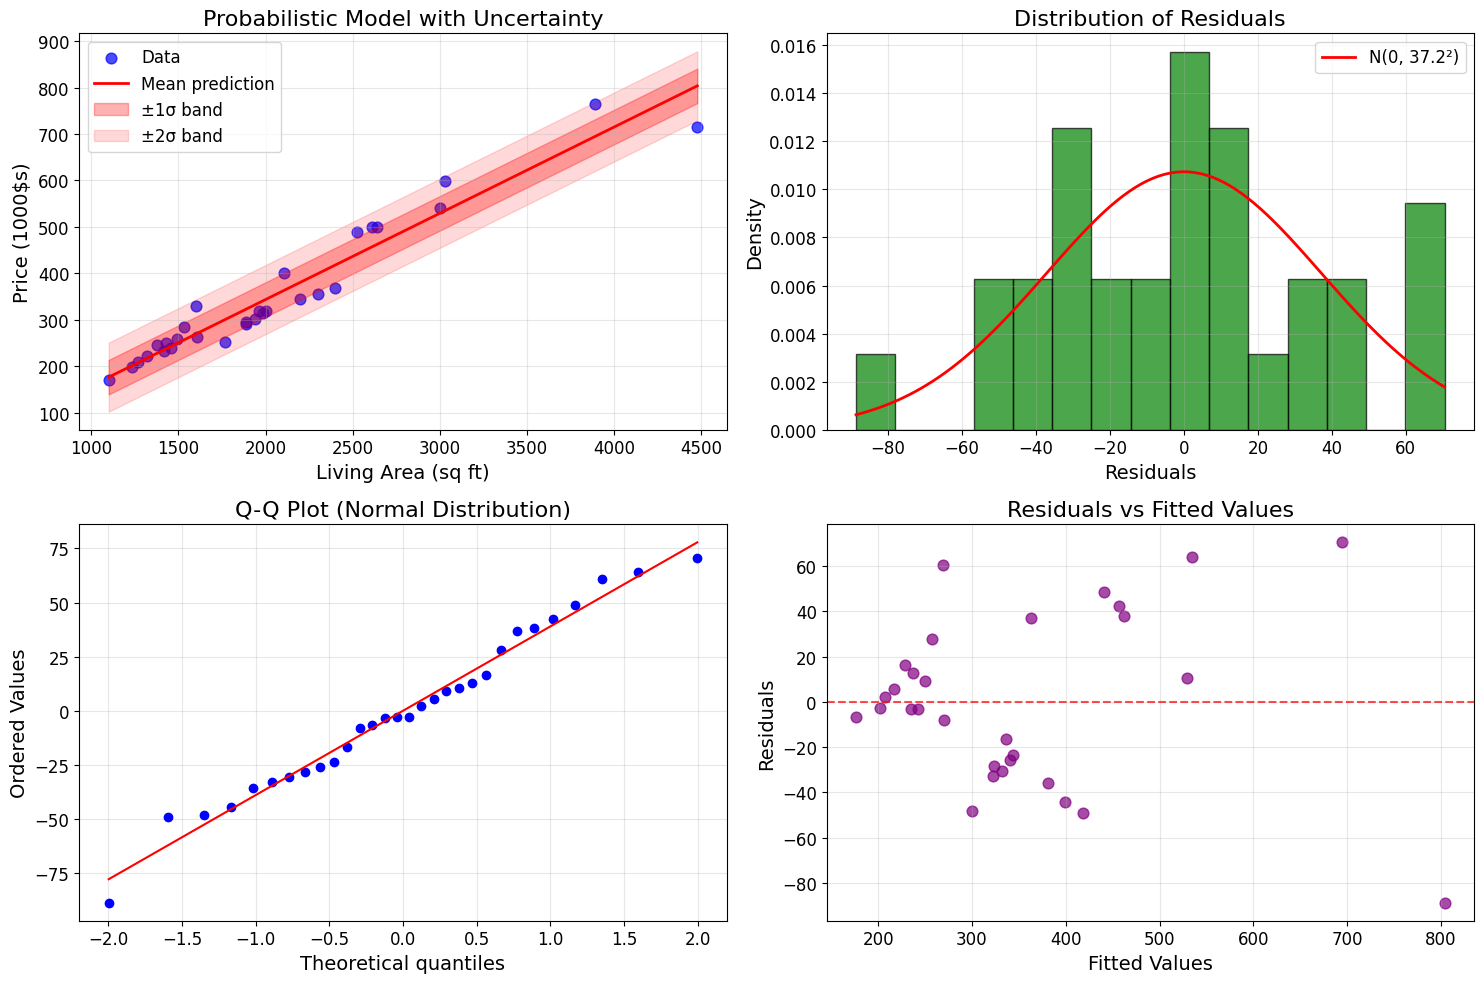

In [22]:
# Demonstrate the probabilistic interpretation
print("Probabilistic Interpretation of Linear Regression")
print("=" * 50)

# Use our fitted model to demonstrate the concepts
predictions = linear_hypothesis(X_single, theta_normal)
residuals = prices - predictions
sigma_estimate = np.std(residuals)

print(f"Estimated noise standard deviation: σ = {sigma_estimate:.2f}")
print(f"Mean of residuals: {np.mean(residuals):.4f} (should be ≈ 0)")

# Test if residuals are approximately normally distributed
from scipy import stats

# Shapiro-Wilk test for normality
statistic, p_value = stats.shapiro(residuals)
print(f"\nNormality test (Shapiro-Wilk):")
print(f"Statistic: {statistic:.4f}, p-value: {p_value:.4f}")
print(f"Residuals are {'approximately normal' if p_value > 0.05 else 'not normal'} (α = 0.05)")

# Visualize the probabilistic model
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Data with uncertainty bands
axes[0, 0].scatter(living_areas, prices, alpha=0.7, s=60, color='blue', label='Data')
x_line = np.linspace(living_areas.min(), living_areas.max(), 100)
y_line = theta_normal[0] + theta_normal[1] * x_line
axes[0, 0].plot(x_line, y_line, 'r-', linewidth=2, label='Mean prediction')

# Add uncertainty bands (±1σ and ±2σ)
axes[0, 0].fill_between(x_line, y_line - sigma_estimate, y_line + sigma_estimate, 
                       alpha=0.3, color='red', label='±1σ band')
axes[0, 0].fill_between(x_line, y_line - 2*sigma_estimate, y_line + 2*sigma_estimate, 
                       alpha=0.15, color='red', label='±2σ band')
axes[0, 0].set_xlabel('Living Area (sq ft)')
axes[0, 0].set_ylabel('Price (1000$s)')
axes[0, 0].set_title('Probabilistic Model with Uncertainty')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Residuals histogram
axes[0, 1].hist(residuals, bins=15, alpha=0.7, color='green', edgecolor='black', density=True)
# Overlay theoretical normal distribution
x_norm = np.linspace(residuals.min(), residuals.max(), 100)
y_norm = stats.norm.pdf(x_norm, np.mean(residuals), sigma_estimate)
axes[0, 1].plot(x_norm, y_norm, 'r-', linewidth=2, label=f'N(0, {sigma_estimate:.1f}²)')
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Distribution of Residuals')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Q-Q plot for normality
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot (Normal Distribution)')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Residuals vs fitted values
axes[1, 1].scatter(predictions, residuals, alpha=0.7, s=60, color='purple')
axes[1, 1].axhline(y=0, color='red', linestyle='--', alpha=0.7)
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].set_title('Residuals vs Fitted Values')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5.2 Maximum Likelihood Estimation

Given our probabilistic model, we can derive the least squares cost function using **maximum likelihood estimation**.

The **likelihood** of the parameters given the data is:
$$L(\theta) = \prod_{i=1}^{n} p(y^{(i)} | x^{(i)}; \theta)$$

Since $y^{(i)} | x^{(i)}; \theta \sim \mathcal{N}(\theta^T x^{(i)}, \sigma^2)$:

$$p(y^{(i)} | x^{(i)}; \theta) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{(y^{(i)} - \theta^T x^{(i)})^2}{2\sigma^2}\right)$$

Therefore:
$$L(\theta) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi}\sigma} \exp\left(-\frac{(y^{(i)} - \theta^T x^{(i)})^2}{2\sigma^2}\right)$$

The **log-likelihood** is:
$$\ell(\theta) = \log L(\theta) = n\log\frac{1}{\sqrt{2\pi}\sigma} - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (y^{(i)} - \theta^T x^{(i)})^2$$

**Maximizing** the log-likelihood is equivalent to **minimizing**:
$$\frac{1}{2} \sum_{i=1}^{n} (y^{(i)} - \theta^T x^{(i)})^2$$

This is exactly our **least squares cost function** $J(\theta)$!

Maximum Likelihood Estimation Connection
Log-likelihood at optimal theta: -151.03

MLE solution: [-27.75140262   0.18567386]
Normal equations: [-27.75227498   0.18567424]
Difference: [8.72353017e-04 3.80915347e-07]


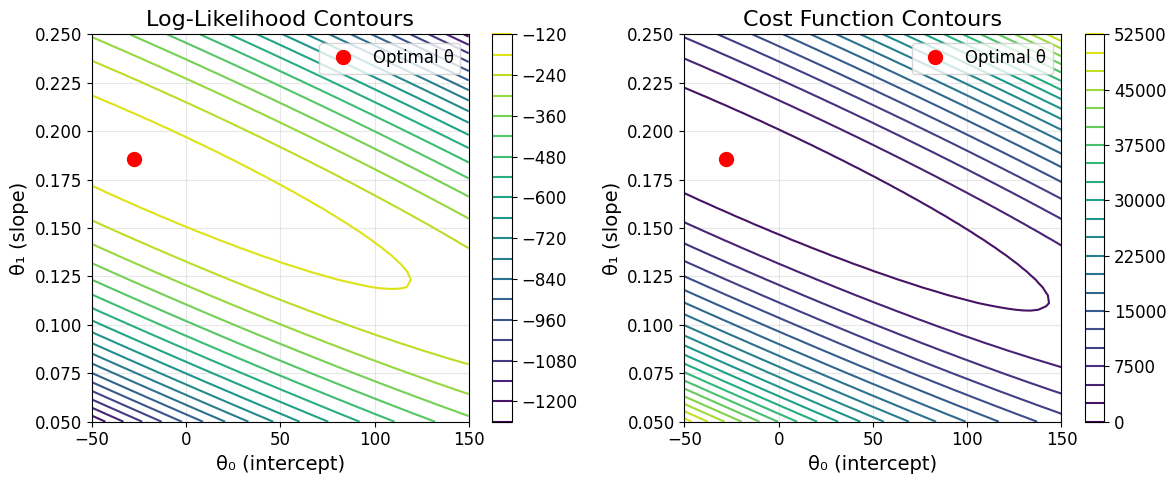


Key insight: Maximizing likelihood ≡ Minimizing least squares cost
This justifies the choice of least squares from a probabilistic perspective!


In [23]:
def log_likelihood(theta, X, y, sigma):
    """
    Compute log-likelihood for linear regression with Gaussian noise
    
    Args:
        theta: Parameter vector
        X: Feature matrix
        y: Target vector
        sigma: Noise standard deviation
    
    Returns:
        log_likelihood: Log-likelihood value
    """
    n = len(y)
    predictions = linear_hypothesis(X, theta)
    residuals_sq = (y - predictions) ** 2
    
    log_lik = n * np.log(1 / (np.sqrt(2 * np.pi) * sigma)) - (1 / (2 * sigma**2)) * np.sum(residuals_sq)
    return log_lik

def negative_log_likelihood(theta, X, y, sigma):
    """Negative log-likelihood (for minimization)"""
    return -log_likelihood(theta, X, y, sigma)

# Demonstrate the connection between MLE and least squares
print("Maximum Likelihood Estimation Connection")
print("=" * 40)

# Compute log-likelihood for our solution
log_lik = log_likelihood(theta_normal, X_single, prices, sigma_estimate)
print(f"Log-likelihood at optimal theta: {log_lik:.2f}")

# Show that minimizing negative log-likelihood gives same result as least squares
from scipy.optimize import minimize

# Optimize using negative log-likelihood
result = minimize(negative_log_likelihood, 
                 x0=np.array([0, 0]), 
                 args=(X_single, prices, sigma_estimate),
                 method='BFGS')

theta_mle = result.x
print(f"\nMLE solution: {theta_mle}")
print(f"Normal equations: {theta_normal}")
print(f"Difference: {np.abs(theta_mle - theta_normal)}")

# Visualize likelihood surface
theta0_range = np.linspace(-50, 150, 50)
theta1_range = np.linspace(0.05, 0.25, 50)
THETA0, THETA1 = np.meshgrid(theta0_range, theta1_range)
LOG_LIK = np.zeros_like(THETA0)

for i in range(len(theta0_range)):
    for j in range(len(theta1_range)):
        theta_test = np.array([THETA0[j, i], THETA1[j, i]])
        LOG_LIK[j, i] = log_likelihood(theta_test, X_single, prices, sigma_estimate)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
contour = plt.contour(THETA0, THETA1, LOG_LIK, levels=20)
plt.plot(theta_normal[0], theta_normal[1], 'ro', markersize=10, label='Optimal θ')
plt.xlabel('θ₀ (intercept)')
plt.ylabel('θ₁ (slope)')
plt.title('Log-Likelihood Contours')
plt.legend()
plt.colorbar(contour)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Show equivalent cost function contours
COST = np.zeros_like(THETA0)
for i in range(len(theta0_range)):
    for j in range(len(theta1_range)):
        theta_test = np.array([THETA0[j, i], THETA1[j, i]])
        COST[j, i] = cost_function(X_single, prices, theta_test)

contour2 = plt.contour(THETA0, THETA1, COST, levels=20)
plt.plot(theta_normal[0], theta_normal[1], 'ro', markersize=10, label='Optimal θ')
plt.xlabel('θ₀ (intercept)')
plt.ylabel('θ₁ (slope)')
plt.title('Cost Function Contours')
plt.legend()
plt.colorbar(contour2)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey insight: Maximizing likelihood ≡ Minimizing least squares cost")
print("This justifies the choice of least squares from a probabilistic perspective!")

---

# Summary and Key Takeaways

## What We've Learned

### 1. **Supervised Learning Framework**
- **Goal**: Learn a hypothesis function $h: \mathcal{X} \mapsto \mathcal{Y}$
- **Components**: Training examples $(x^{(i)}, y^{(i)})$, features, targets
- **Types**: Regression (continuous $y$) vs Classification (discrete $y$)

### 2. **Linear Regression Model**
- **Hypothesis**: $h_\theta(x) = \theta^T x = \theta_0 + \theta_1 x_1 + \cdots + \theta_d x_d$
- **Cost Function**: $J(\theta) = \frac{1}{2} \sum_{i=1}^{n} (h_\theta(x^{(i)}) - y^{(i)})^2$
- **Properties**: Convex optimization, unique global minimum

### 3. **Optimization Methods**

#### **Gradient Descent (LMS Algorithm)**
- **Update Rule**: $\theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta)$
- **Batch GD**: Uses all examples per update
- **Stochastic GD**: Uses one example per update, faster for large datasets
- **Key**: Requires feature normalization for good performance

#### **Normal Equations**
- **Closed-form**: $\theta = (X^T X)^{-1} X^T \vec{y}$
- **Advantages**: Exact solution, no iterations, no learning rate
- **Disadvantages**: $O(d^3)$ complexity, memory intensive for large $d$

### 4. **Probabilistic Justification**
- **Model**: $y^{(i)} = \theta^T x^{(i)} + \epsilon^{(i)}$ where $\epsilon^{(i)} \sim \mathcal{N}(0, \sigma^2)$
- **Maximum Likelihood Estimation** leads naturally to least squares cost function
- **Provides theoretical foundation** for linear regression

### 5. **Practical Guidelines**

| Scenario | Recommended Method | Notes |
|----------|-------------------|-------|
| Small datasets ($n < 1000, d < 100$) | Normal Equations | Fast, exact |
| Medium datasets ($d < 1000$) | Either method | Normal equations often faster |
| Large datasets ($d > 1000$ or $n > 10^6$) | Gradient Descent | Scalable, memory efficient |
| Online learning | Stochastic GD | Can adapt to new data |

## Implementation Checklist 

- **Data preprocessing**: Handle missing values, outliers
- **Feature normalization**: Essential for gradient descent
- **Parameter initialization**: Start with zeros or small random values
- **Learning rate tuning**: Start with 0.01, adjust based on convergence
- **Convergence monitoring**: Track cost function, check for oscillations
- **Model validation**: Check residuals, test normality assumptions

## Next Steps

This foundation in linear regression enables understanding of:
- **Regularization** (Ridge, Lasso regression)
- **Logistic regression** for classification
- **Neural networks** as extensions of linear models
- **Advanced optimization** methods (Adam, RMSprop)

